# Lung Sound Classificaation using Machine Learning

## Objective
Build a machine learning model that classifies lung sound into different medical conditions using audio recordings

## Dataset
HLS_CMDS: Heart and Lung sounds Dataset (UCI Repository)

We use:
- LS.csv (labels + metadata)
- WAV files (audio signals)

Each Lung Sound ID corresponds to a .wav file

In [1]:
import pandas as pd
import numpy as np 
import os 
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load the dataset
df = pd.read_csv("../dataset/LS.csv")

print(df.head())
print(df["Lung Sound Type"].value_counts())

  Gender Lung Sound Type Location Lung Sound ID
0      M          Normal      RUA       M_N_RUA
1      F          Normal      LUA       F_N_LUA
2      F          Normal      RMA       F_N_RMA
3      F          Normal      LMA       F_N_LMA
4      M          Normal      RLA       M_N_RLA
Lung Sound Type
Normal             12
Pleural Rub         9
Coarse Crackles     9
Rhonchi             8
Wheezing            7
Fine Crackles       5
Name: count, dtype: int64


In [3]:
# clean data
counts = df["Lung Sound Type"].value_counts()

valid_classes = counts[counts >= 5].index
df = df[df["Lung Sound Type"].isin(valid_classes)]

print("Final classes: \n", df["Lung Sound Type"].value_counts())

Final classes: 
 Lung Sound Type
Normal             12
Pleural Rub         9
Coarse Crackles     9
Rhonchi             8
Wheezing            7
Fine Crackles       5
Name: count, dtype: int64


In [4]:
# Map audio filepaths
df["Lung Sound ID"] = df["Lung Sound ID"].astype(str).str.strip()

base_path= "../dataset/LS"

df["filepath"] = df["Lung Sound ID"].apply(
    lambda x: os.path.join(base_path, x+ ".wav")
)

In [5]:
# feature extraction
X = []
y = []

valid_count = 0

for _, row in df.iterrows():
    path = row["filepath"]
    label = row["Lung Sound Type"]

    if not os.path.exists(path):
        print("Missing:", path)
        continue
    
    try:
        audio, sr = librosa.load(path, sr = 22050)
        mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20), axis=1)

        zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
        rms = np.mean(librosa.feature.rms(y=audio))
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))

        features = np.hstack([mfcc, zcr, rms, centroid, bandwidth])

        X.append(features)
        y.append(label)

        valid_count += 1

    except Exception as e:
        print("Error:", path, e)

print("Valid samples loaded:", valid_count)

    

Valid samples loaded: 50


In [6]:
# converting to ml format
X = np.array(X)
y = np.array(y)

print("X shape: ", X.shape)
print("y shape: ", y.shape)


X shape:  (50, 24)
y shape:  (50,)


In [7]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# Model pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In [10]:
# Train Model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U15](6,)","['Coarse Crackles','Fine Crackles','Normal','Pleural Rub','Rhonchi', 'Wheezing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [11]:
# Test Performance Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6

Classification Report:

                 precision    recall  f1-score   support

Coarse Crackles       0.67      1.00      0.80         2
  Fine Crackles       0.00      0.00      0.00         1
         Normal       0.00      0.00      0.00         2
    Pleural Rub       0.67      1.00      0.80         2
        Rhonchi       0.50      0.50      0.50         2
       Wheezing       0.50      1.00      0.67         1

       accuracy                           0.60        10
      macro avg       0.39      0.58      0.46        10
   weighted avg       0.42      0.60      0.49        10



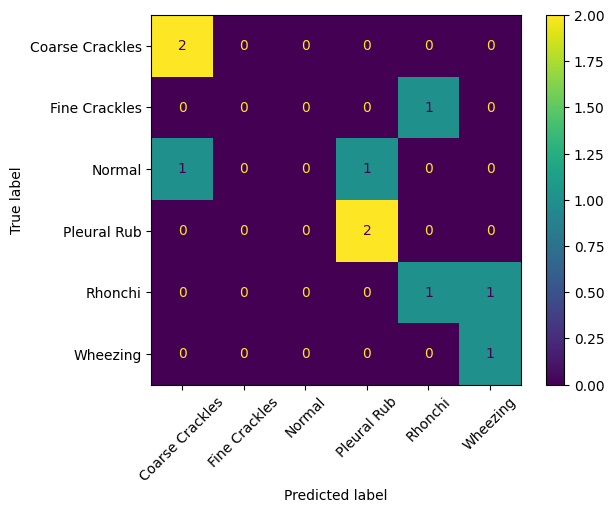

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.show()

In [13]:
# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

Cross Validation Scores: [0.8 0.5 0.5 0.7 0.6]
Mean Accuracy: 0.62
Std: 0.11661903789690602


In [14]:
# Train on full data
model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U15](6,)","['Coarse Crackles','Fine Crackles','Normal','Pleural Rub','Rhonchi', 'Wheezing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [17]:
# single prediction function
def predict_lung(file_path):

    audio, sr = librosa.load(file_path, sr=22050)

    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20), axis=1)

    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
    rms = np.mean(librosa.feature.rms(y=audio))
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))

    features = np.hstack([mfcc, zcr, rms, centroid, bandwidth]).reshape(1, -1)

    return model.predict(features)[0]

In [18]:
print(predict_lung("../dataset/LS/F_PR_LLA.wav"))

Pleural Rub
